In [19]:
import numpy as np

import pandas as pd 

import matplotlib.pyplot as plt

import seaborn as sns

In [4]:
df= pd.read_csv('stroke.csv',index_col="id").sort_index()

df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
67,Female,17.0,0,0,No,Private,Urban,92.97,NaN,formerly smoked,0
77,Female,13.0,0,0,No,children,Rural,85.81,18.6,Unknown,0
84,Male,55.0,0,0,Yes,Private,Urban,89.17,31.5,never smoked,0
91,Female,42.0,0,0,No,Private,Urban,98.53,18.5,never smoked,0
99,Female,31.0,0,0,No,Private,Urban,108.89,52.3,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...
72911,Female,57.0,1,0,Yes,Private,Rural,129.54,60.9,smokes,0
72914,Female,19.0,0,0,No,Private,Urban,90.57,24.2,Unknown,0
72915,Female,45.0,0,0,Yes,Private,Urban,172.33,45.3,formerly smoked,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 5110 entries, 67 to 72940
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 479.1 KB


In [15]:
FIGSIZE = (6,4)

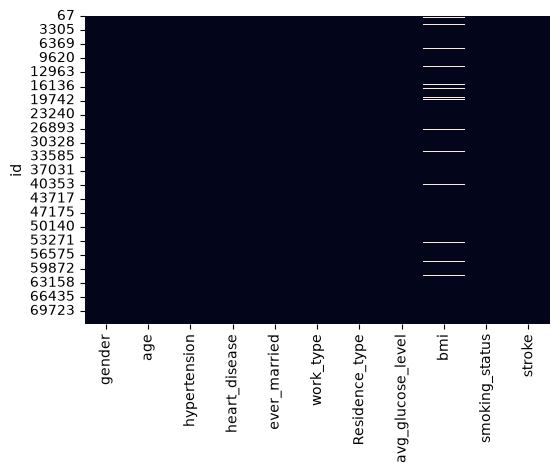

In [20]:
plt.figure(figsize=FIGSIZE)
sns.heatmap(df.isna(),cbar=False)
plt.show()

In [6]:
df["hypertension"].value_counts()

hypertension
0    4612
1     498
Name: count, dtype: int64

In [8]:
for col in df.columns :
    display(df[col].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

age
78.00    102
57.00     95
52.00     90
54.00     87
51.00     86
        ... 
0.16       3
0.48       3
1.40       3
0.40       2
0.08       2
Name: count, Length: 104, dtype: int64

hypertension
0    4612
1     498
Name: count, dtype: int64

heart_disease
0    4834
1     276
Name: count, dtype: int64

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

...

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

avg_glucose_level
93.88     6
72.49     5
91.68     5
83.16     5
91.85     5
         ..
129.54    1
90.57     1
172.33    1
62.55     1
102.92    1
Name: count, Length: 3979, dtype: int64

bmi
28.7    41
28.4    38
27.6    37
26.7    37
26.1    37
        ..
64.8     1
51.0     1
64.4     1
54.1     1
61.6     1
Name: count, Length: 418, dtype: int64

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

stroke
0    4861
1     249
Name: count, dtype: int64

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [22]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [23]:
cont_feature = df[['age','avg_glucose_level','bmi']]

cat_feature = df.drop(columns=['age','avg_glucose_level','bmi'])

### analyse univarié

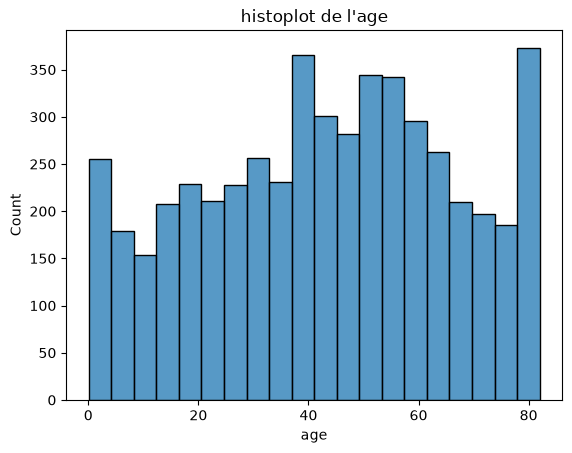

In [24]:
plt.Figure(figsize=FIGSIZE)

plt.title("histoplot de l'age")

sns.histplot(data=cont_feature,x='age')

plt.show()

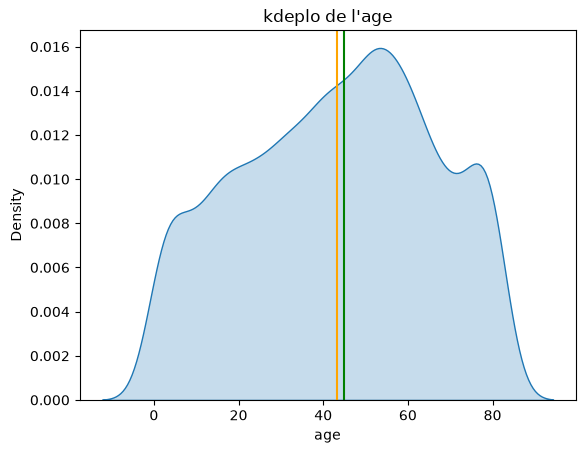

In [28]:
plt.Figure(figsize=FIGSIZE)

plt.title("kdeplo de l'age")

sns.kdeplot(data=cont_feature,x='age',fill=True)

plt.axvline(x=cont_feature['age'].mean(),c="orange", label="moyenne")
plt.axvline(x=cont_feature['age'].median(),c="green", label="medianne")

plt.show()

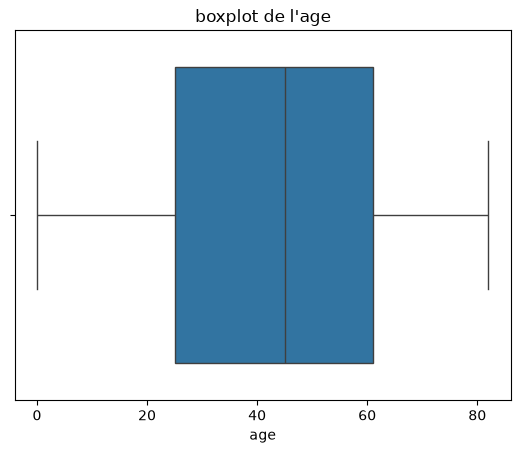

In [26]:
plt.Figure(figsize=FIGSIZE)

plt.title("boxplot de l'age")

sns.boxplot(data=cont_feature,x='age')

plt.show()

### moustache superieur = q3 + (1.5 *(q3-q1))
### moustache inferieur =  q3 - (1.5*(q3-q1))

In [27]:
q1 = df['bmi'].quantile(0.25)

q3 = df['bmi'].quantile(0.75)

iqr = q3 - q1

df[df['bmi'] > (q3 + (1.5* iqr))]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
99,Female,31.0,0,0,No,Private,Urban,108.89,52.3,Unknown,0
545,Male,42.0,0,0,Yes,Private,Rural,210.48,71.9,never smoked,0
1307,Female,61.0,1,0,Yes,Private,Rural,170.05,60.2,smokes,0
1696,Female,43.0,0,0,Yes,Private,Urban,100.88,47.6,smokes,0
1703,Female,52.0,0,0,Yes,Private,Urban,82.24,54.7,formerly smoked,0
...,...,...,...,...,...,...,...,...,...,...,...
69834,Female,57.0,0,0,Yes,Govt_job,Rural,87.10,48.3,smokes,0
70670,Female,27.0,0,0,Yes,Private,Rural,57.96,64.4,never smoked,0
72696,Female,53.0,0,0,Yes,Private,Urban,70.51,54.1,never smoked,0


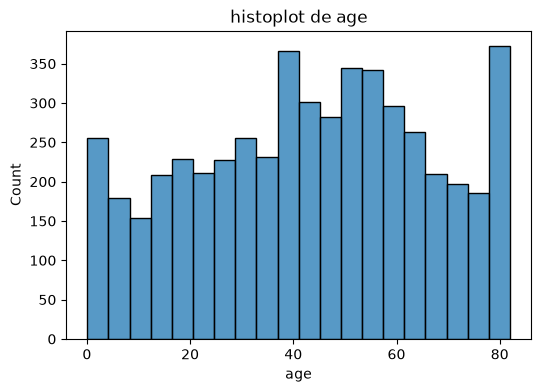

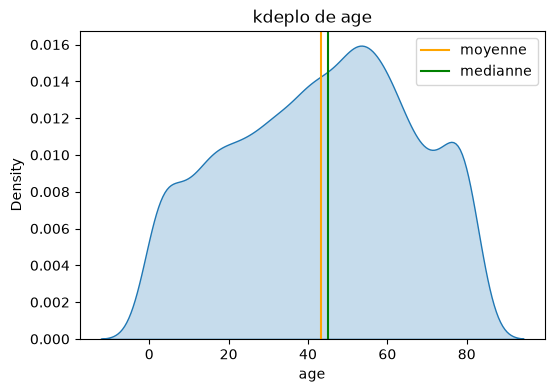

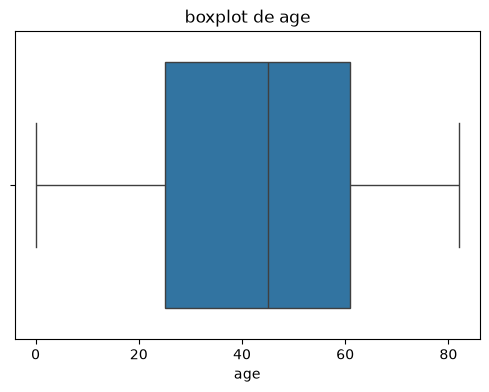

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

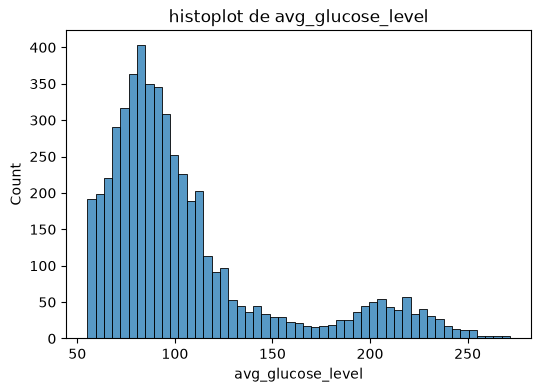

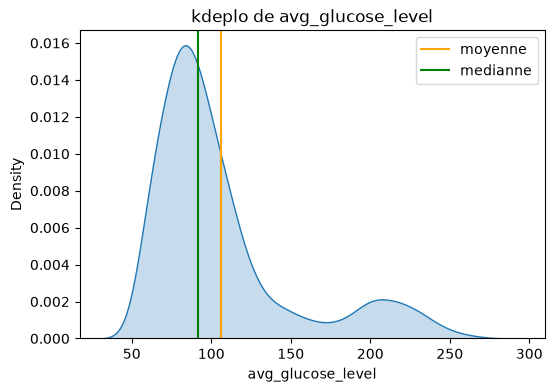

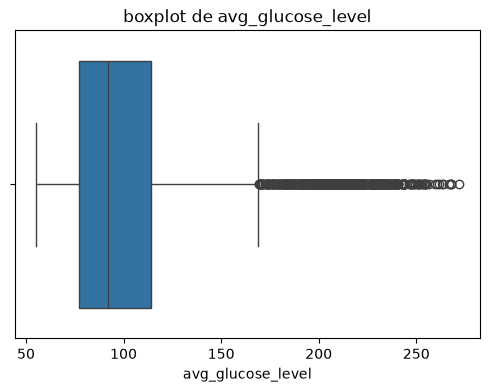

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

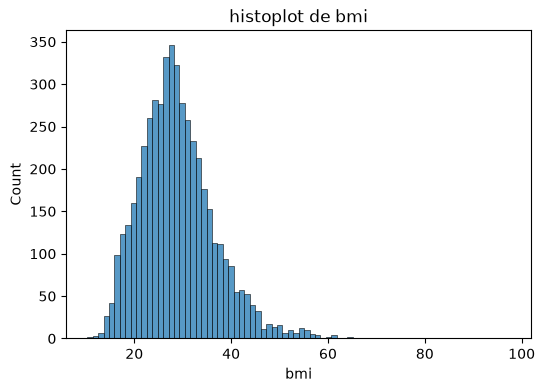

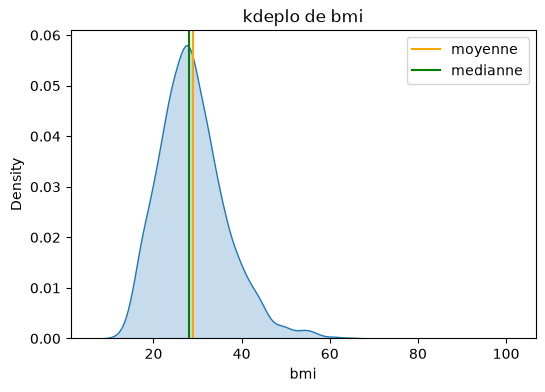

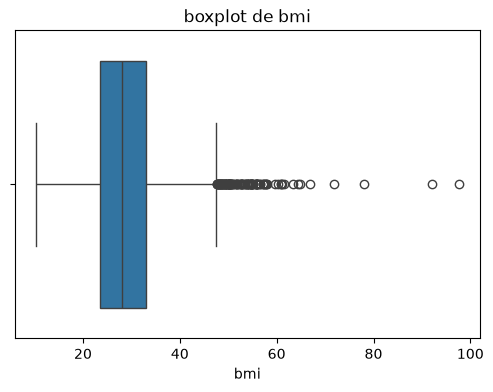

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [38]:
for col in cont_feature.columns:
    plt.figure(figsize=FIGSIZE)

    plt.title(f"histoplot de {col}")

    sns.histplot(data=cont_feature,x=col)

    plt.show()

    plt.figure(figsize=FIGSIZE)

    plt.title(f"kdeplo de {col}")

    sns.kdeplot(data=cont_feature,x=col,fill=True)

    plt.axvline(x=cont_feature[col].mean(),c="orange", label="moyenne")
    plt.axvline(x=cont_feature[col].median(),c="green", label="medianne")
    plt.legend()
    plt.show()

    plt.figure(figsize=FIGSIZE)

    plt.title(f"boxplot de {col}")

    sns.boxplot(data=cont_feature,x=col)

    plt.show()

    display(df[col].describe())

### univarie


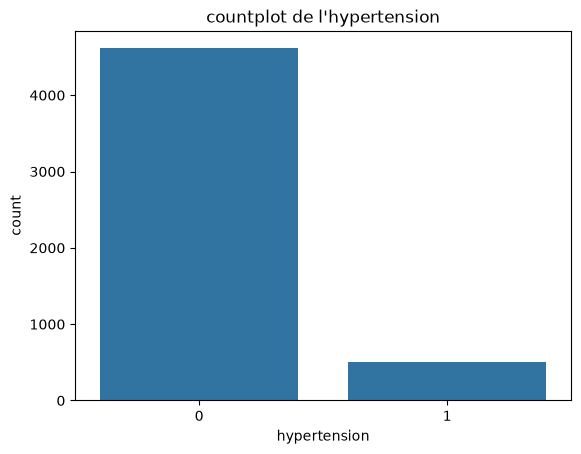

hypertension
0    4612
1     498
Name: count, dtype: int64

In [40]:
plt.Figure()
plt.title("countplot de l'hypertension")

sns.countplot(data=cat_feature,x="hypertension")

plt.show()

cat_feature['hypertension'].value_counts()

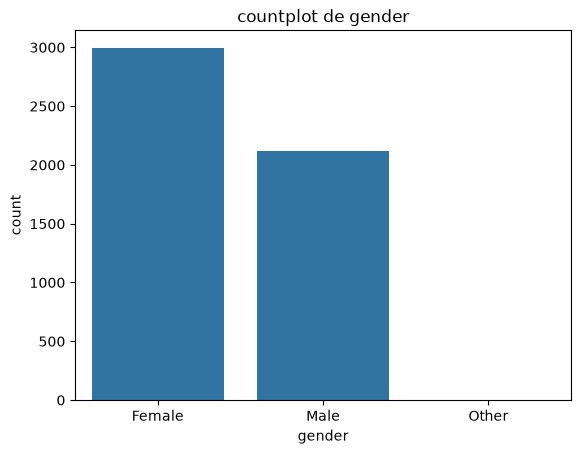

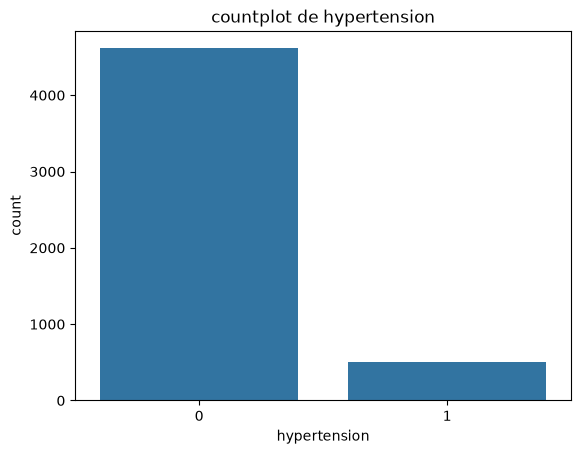

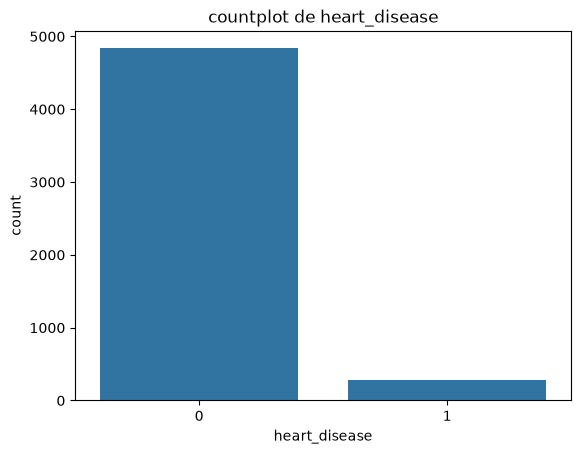

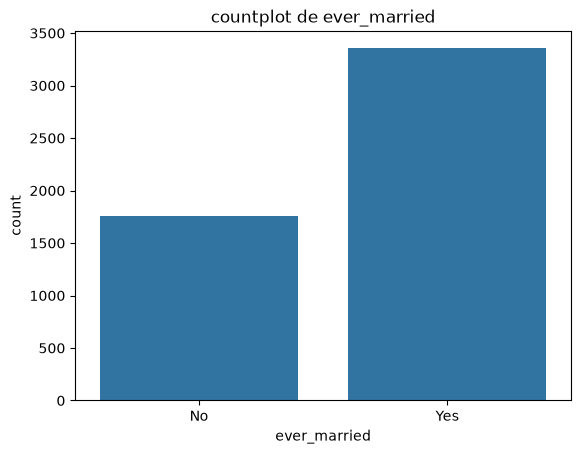

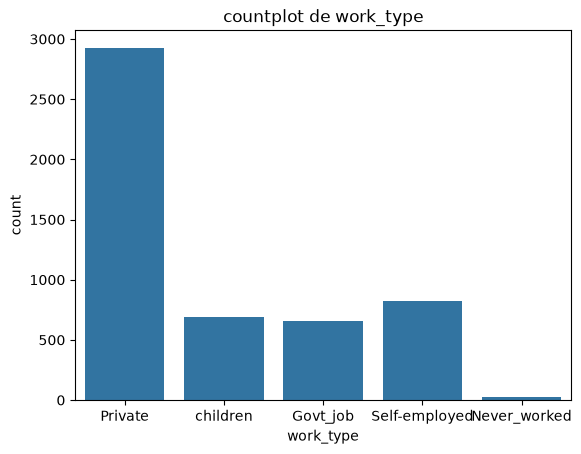

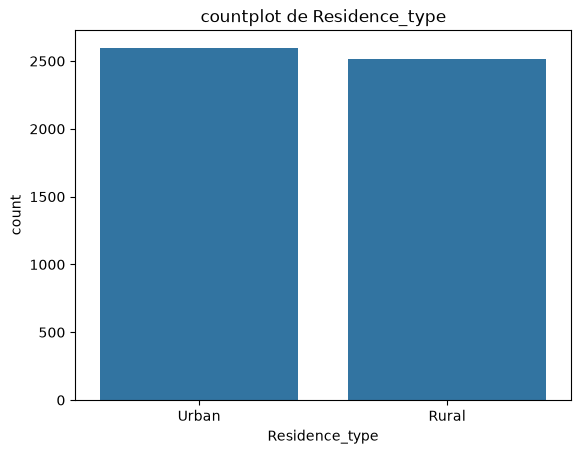

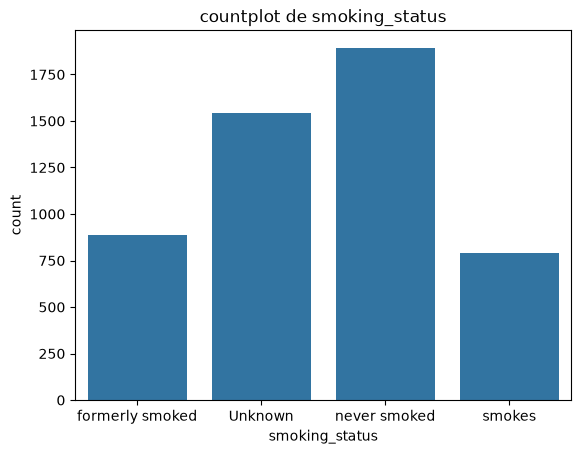

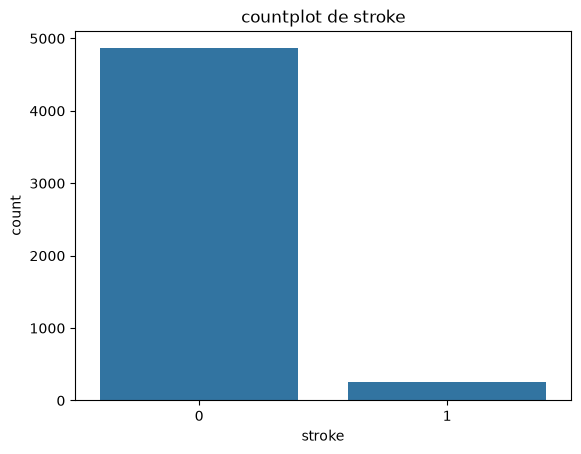

In [41]:
for col in cat_feature.columns:
    plt.Figure()
    plt.title(f"countplot de {col}")

    sns.countplot(data=cat_feature,x=col)

    plt.show()

    cat_feature[col].value_counts()

In [44]:
df[df['work_type'] == 'Never_worked'].describe().T

,count,mean,std,min,25%,50%,75%,max
age,22.0,16.181818,2.342899,13.00,14.2500,16.00,17.0000,23.00
hypertension,22.0,0.000000,0.000000,0.00,0.0000,0.00,0.0000,0.00
heart_disease,22.0,0.000000,0.000000,0.00,0.0000,0.00,0.0000,0.00
avg_glucose_level,22.0,96.042727,28.697132,59.99,78.4575,86.02,112.8075,161.28
bmi,22.0,25.545455,7.441757,14.60,20.9750,23.15,28.3500,44.90
stroke,22.0,0.000000,0.000000,0.00,0.0000,0.00,0.0000,0.00


### en bivarié

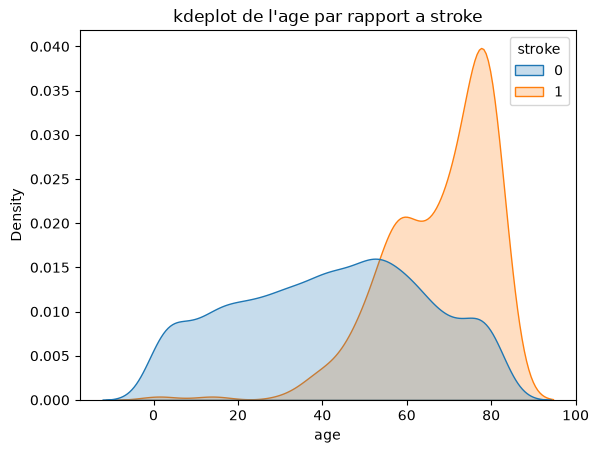

In [46]:
plt.Figure(figsize=FIGSIZE)
plt.title("kdeplot de l'age par rapport a stroke")
sns.kdeplot(data=cont_feature,x='age',fill=True,hue=df['stroke'],common_norm=False)
plt.show()

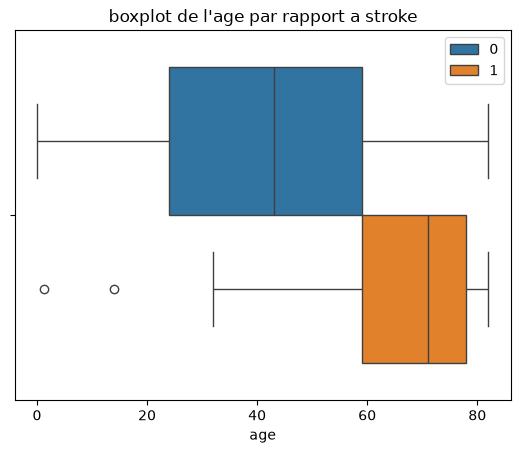

In [48]:
plt.Figure(figsize=FIGSIZE)
plt.title("boxplot de l'age par rapport a stroke")
sns.boxplot(data=cont_feature,x='age',hue=df['stroke'])
plt.legend()
plt.show()

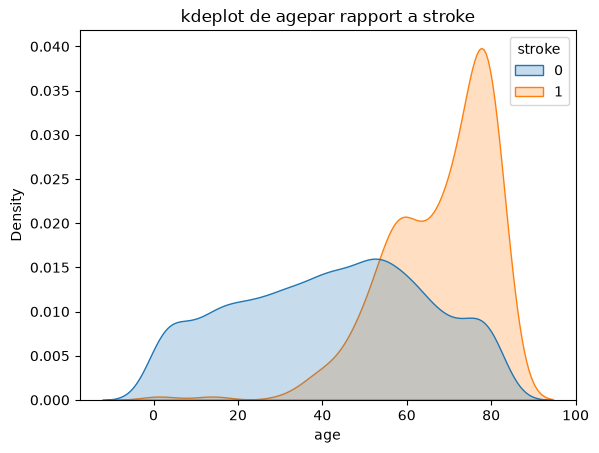

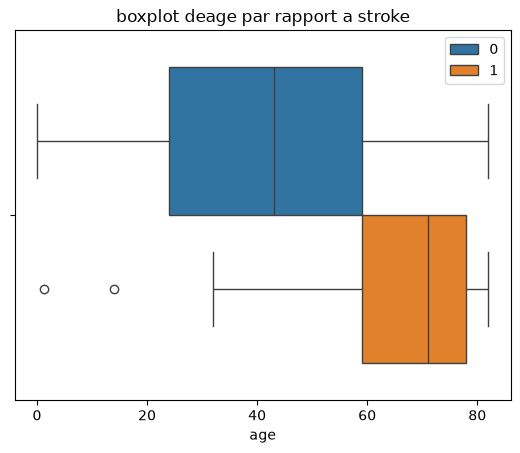

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4861.0,41.971545,22.291940,0.08,24.0,43.0,59.0,82.0
1,249.0,67.728193,12.727419,1.32,59.0,71.0,78.0,82.0


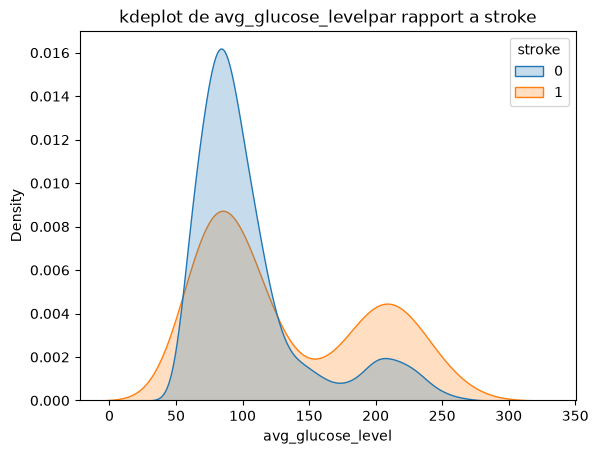

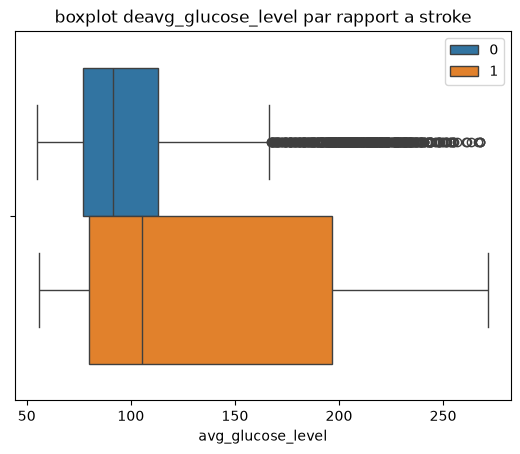

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4861.0,104.795513,43.846069,55.12,77.12,91.47,112.83,267.76
1,249.0,132.544739,61.921056,56.11,79.79,105.22,196.71,271.74


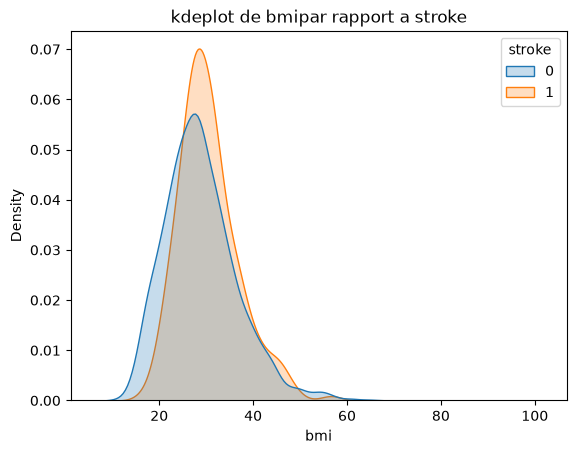

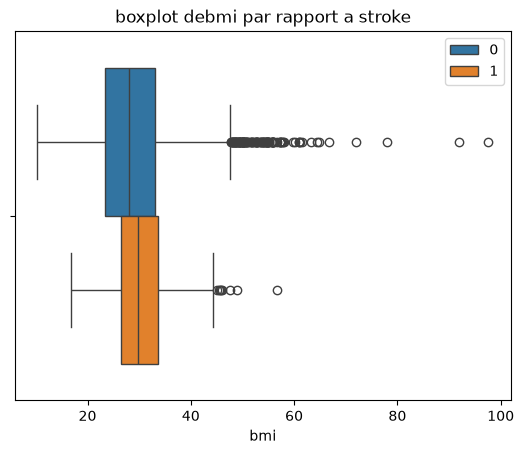

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4700.0,28.823064,7.908287,10.3,23.4,28.0,33.1,97.6
1,209.0,30.471292,6.329452,16.9,26.4,29.7,33.7,56.6


In [49]:
for col in cont_feature.columns:

    plt.Figure(figsize=FIGSIZE)
    plt.title(f"kdeplot de {col}par rapport a stroke")
    sns.kdeplot(data=cont_feature,x=col,fill=True,hue=df['stroke'],common_norm=False)
    plt.show()
    plt.Figure(figsize=FIGSIZE)
    plt.title(f"boxplot de{col} par rapport a stroke")
    sns.boxplot(data=cont_feature,x=col ,hue=df['stroke'])
    plt.legend()
    plt.show()

    display(df.groupby(by='stroke').describe()[col])

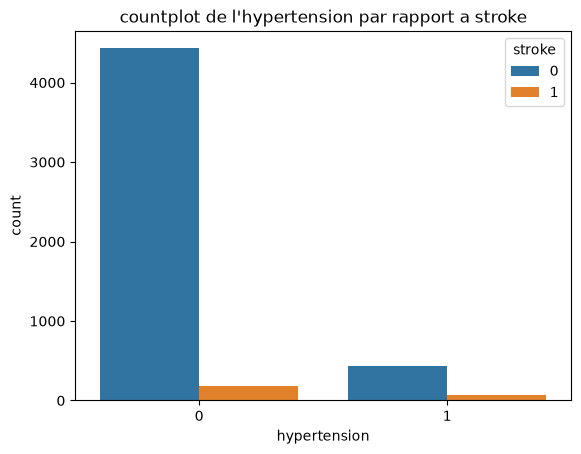

In [50]:
plt.Figure(figsize=FIGSIZE)
plt.title("countplot de l'hypertension par rapport a stroke")
sns.countplot(data=cat_feature,x='hypertension',hue='stroke')
plt.show()

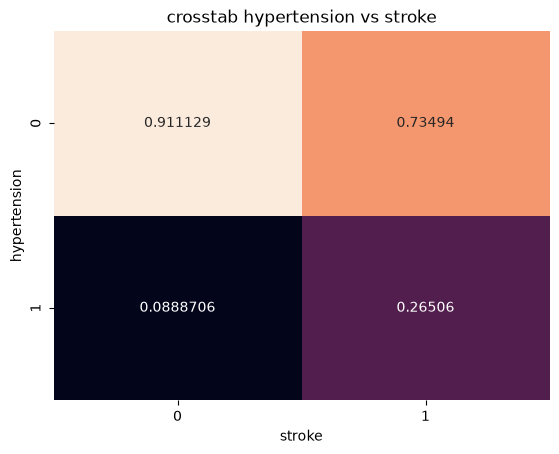

In [57]:
ct = pd.crosstab(index=df['hypertension'],
                 columns=df['stroke'],

                 normalize="columns")


plt.Figure(figsize=FIGSIZE)
plt.title("crosstab hypertension vs stroke")

sns.heatmap(ct,cbar=False,annot=True,fmt="2g")

plt.show()

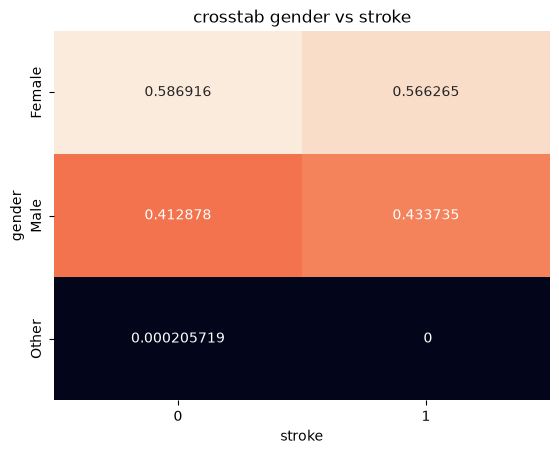

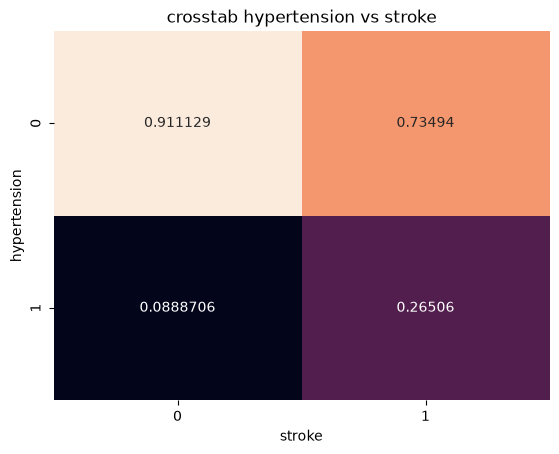

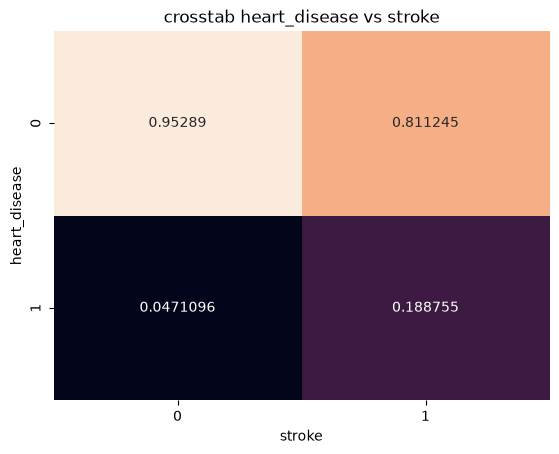

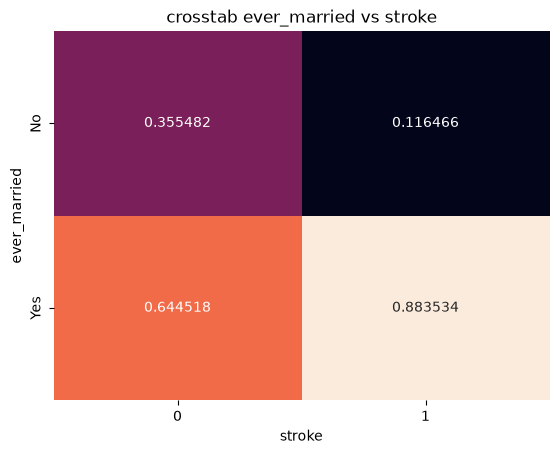

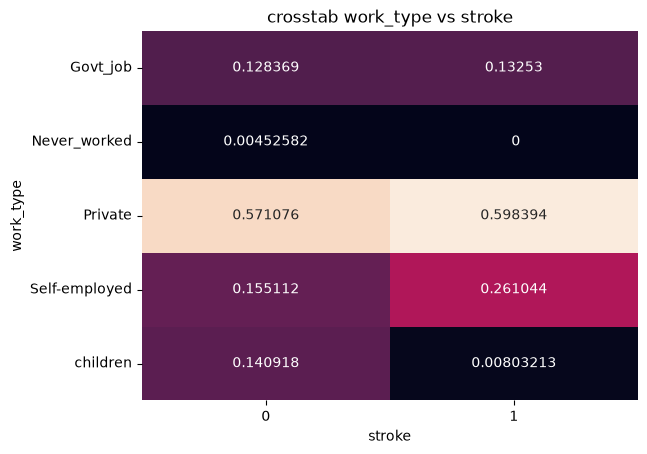

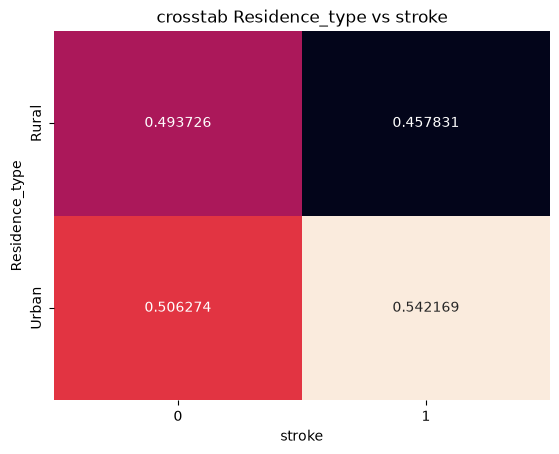

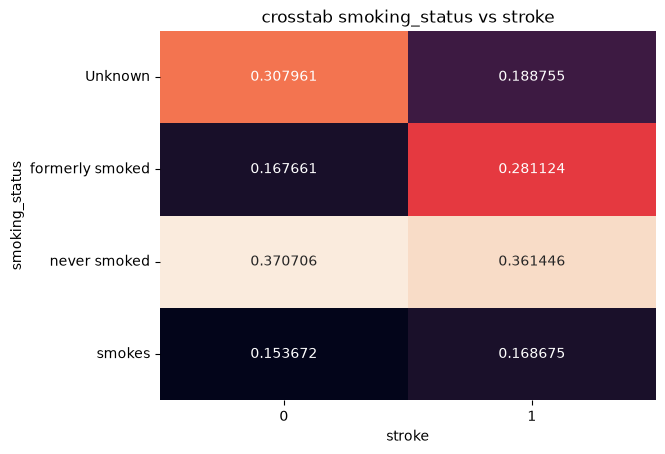

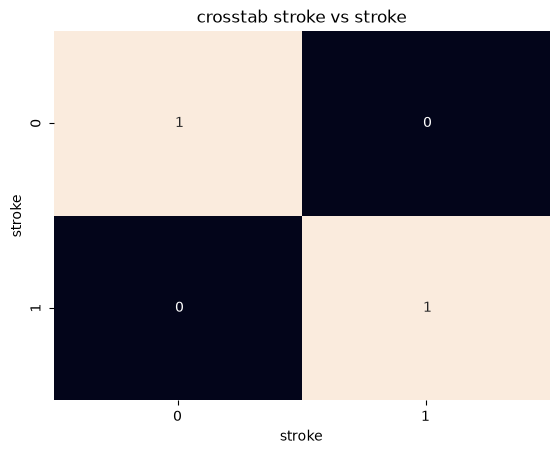

In [58]:
for col in cat_feature.columns:

    

    ct = pd.crosstab(index=df[col],
                    columns=df['stroke'],

                    normalize="columns")


    plt.Figure(figsize=(3,2))
    plt.title(f"crosstab {col} vs stroke")

    sns.heatmap(ct,cbar=False,annot=True,fmt="2g")

    plt.show()